In [23]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

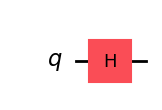

In [24]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [25]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [26]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [27]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [28]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

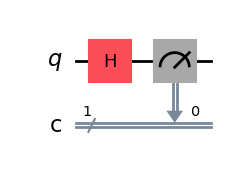

In [29]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [30]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [31]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'0': 525, '1': 499}


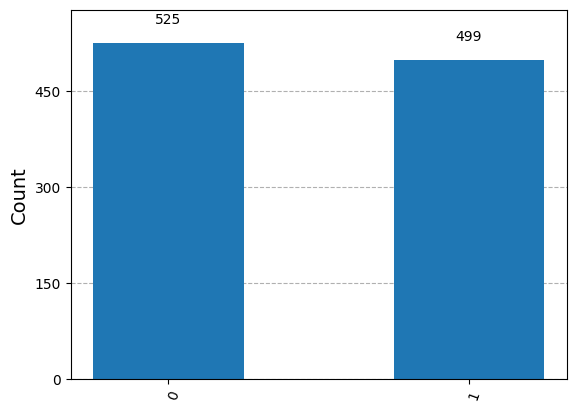

In [32]:
# We can also produce a graph

plot_histogram(counts)

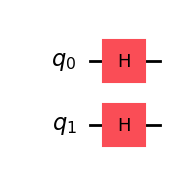

In [33]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [34]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

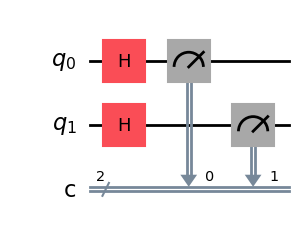

In [35]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

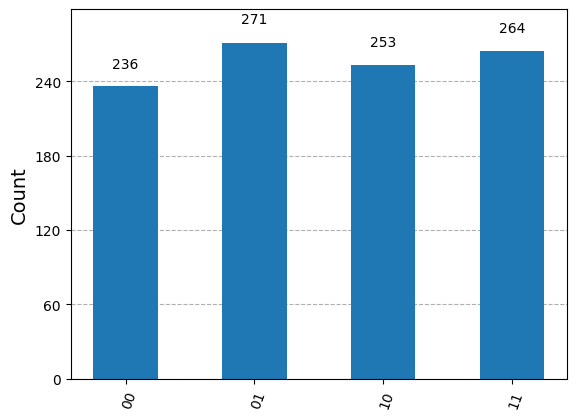

In [36]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

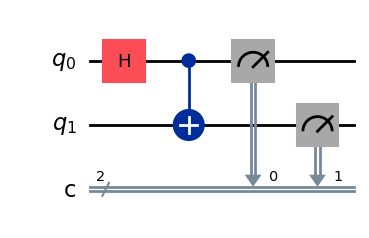

In [37]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

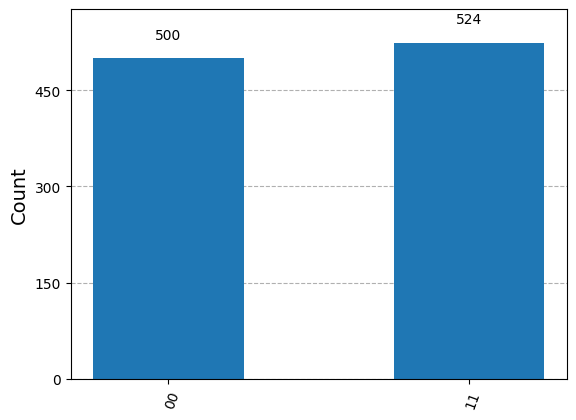

In [38]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

Circuit for |00> + |11>:


<>:15: SyntaxWarning: invalid escape sequence '\P'
<>:38: SyntaxWarning: invalid escape sequence '\P'
<>:66: SyntaxWarning: invalid escape sequence '\P'
<>:15: SyntaxWarning: invalid escape sequence '\P'
<>:38: SyntaxWarning: invalid escape sequence '\P'
<>:66: SyntaxWarning: invalid escape sequence '\P'
/tmp/ipykernel_11519/4203390049.py:15: SyntaxWarning: invalid escape sequence '\P'
  display(array_to_latex(state1, prefix='|\Psi_1\rangle = '))
/tmp/ipykernel_11519/4203390049.py:38: SyntaxWarning: invalid escape sequence '\P'
  display(array_to_latex(state2, prefix='|\Psi_2\rangle = '))
/tmp/ipykernel_11519/4203390049.py:66: SyntaxWarning: invalid escape sequence '\P'
  display(array_to_latex(state4, prefix='|\Psi_4\rangle = '))


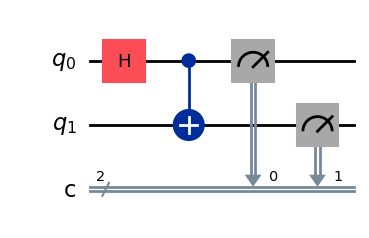

<IPython.core.display.Latex object>

Measurement counts for |00> + |11>: {'00': 506, '11': 518}


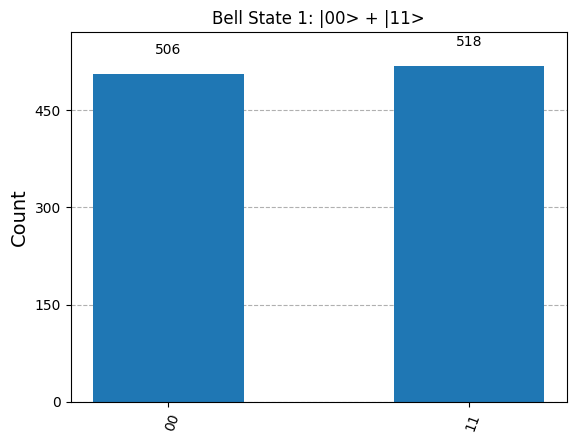

Circuit for |00> - |11>:


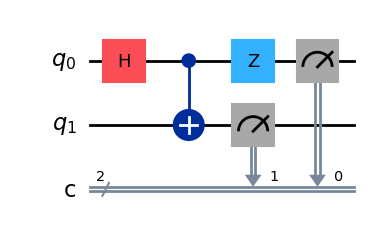

<IPython.core.display.Latex object>

Measurement counts for |00> - |11>: {'00': 509, '11': 515}


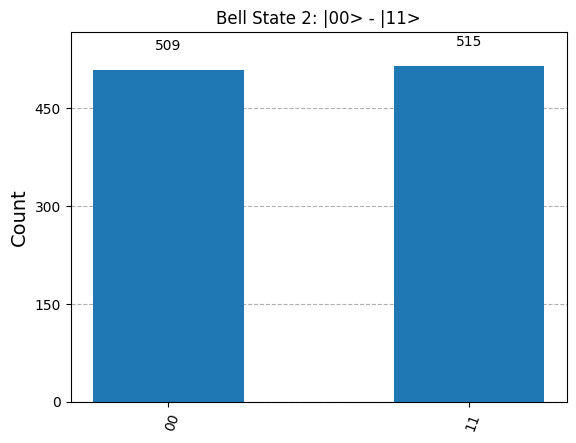

Circuit for |01> - |10>:


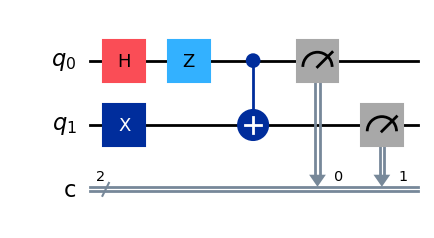

<IPython.core.display.Latex object>

Measurement counts for |01> - |10>: {'01': 517, '10': 507}


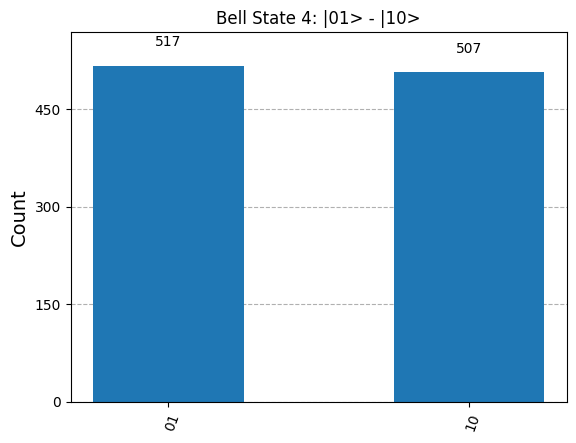

In [40]:
# EXERCISE

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).
circuit1 = QuantumCircuit(2,2)
circuit1.h(0)
circuit1.cx(0,1)
circuit1.measure(range(2),range(2))
print("Circuit for |00> + |11>:")
display(circuit1.draw("mpl"))
# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).
state1_qc = QuantumCircuit(2)
state1_qc.h(0)
state1_qc.cx(0,1)
state1 = Statevector.from_int(0, 4).evolve(state1_qc)
display(array_to_latex(state1, prefix='|\Psi_1\rangle = '))
# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.
qc_compiled1 = transpile(circuit1, backend)
job_sim1 = backend.run(qc_compiled1, shots=1024)
result_sim1 = job_sim1.result()
counts1 = result_sim1.get_counts(qc_compiled1)
print("Measurement counts for |00> + |11>:", counts1)
display(plot_histogram(counts1, title='Bell State 1: |00> + |11>'))

circuit2 = QuantumCircuit(2,2)
circuit2.h(0)
circuit2.cx(0,1)
circuit2.z(0) # Apply Z gate to qubit 0
circuit2.measure(range(2),range(2))
print("Circuit for |00> - |11>:")
display(circuit2.draw("mpl"))

# Verify state vector
state2_qc = QuantumCircuit(2)
state2_qc.h(0)
state2_qc.cx(0,1)
state2_qc.z(0)
state2 = Statevector.from_int(0, 4).evolve(state2_qc)
display(array_to_latex(state2, prefix='|\Psi_2\rangle = '))

# Simulate and plot results
qc_compiled2 = transpile(circuit2, backend)
job_sim2 = backend.run(qc_compiled2, shots=1024)
result_sim2 = job_sim2.result()
counts2 = result_sim2.get_counts(qc_compiled2)
print("Measurement counts for |00> - |11>:", counts2)
display(plot_histogram(counts2, title='Bell State 2: |00> - |11>'))

# Bell State 4: 1/sqrt(2) ( |01> - |10> )
# Start with |01> + |10> and apply Z on qubit 0 to get the minus sign
circuit4 = QuantumCircuit(2,2)
circuit4.x(1) # Initialize qubit 1 to |1>, so starting state is |01>
circuit4.h(0)
circuit4.z(0) # Apply Z gate to qubit 0
circuit4.cx(0,1)
circuit4.measure(range(2),range(2))
print("Circuit for |01> - |10>:")
display(circuit4.draw("mpl"))

# Verify state vector
state4_qc = QuantumCircuit(2)
state4_qc.x(1)
state4_qc.h(0)
state4_qc.z(0)
state4_qc.cx(0,1)
state4 = Statevector.from_int(0, 4).evolve(state4_qc)
display(array_to_latex(state4, prefix='|\Psi_4\rangle = '))

# Simulate and plot results
qc_compiled4 = transpile(circuit4, backend)
job_sim4 = backend.run(qc_compiled4, shots=1024)
result_sim4 = job_sim4.result()
counts4 = result_sim4.get_counts(qc_compiled4)
print("Measurement counts for |01> - |10>:", counts4)
display(plot_histogram(counts4, title='Bell State 4: |01> - |10>'))

# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.


Circuit for 3-qubit GHZ state:


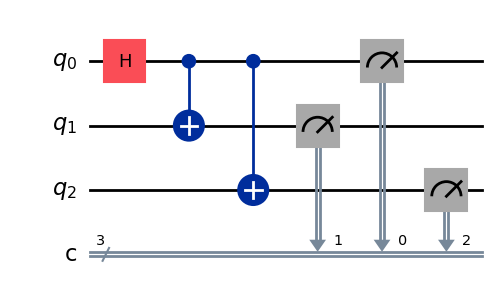

In [41]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.

# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?

def create_ghz_circuit(num_qubits):
    """
    Creates a quantum circuit for a GHZ state on `num_qubits` qubits.
    """
    circuit = QuantumCircuit(num_qubits, num_qubits)

    # Apply Hadamard gate to the first qubit
    circuit.h(0)

    # Apply CNOT gates to entangle all other qubits with the first
    for i in range(1, num_qubits):
        circuit.cx(0, i)

    # Measure all qubits
    circuit.measure(range(num_qubits), range(num_qubits))

    return circuit

# Example: Create a 3-qubit GHZ state
num_qubits_ghz = 3
ghz_circuit = create_ghz_circuit(num_qubits_ghz)

print(f"Circuit for {num_qubits_ghz}-qubit GHZ state:")
display(ghz_circuit.draw("mpl"))